In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 4 extra packages ────────────────────────────────────────────
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
#_______________________________________________________________________

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Load cleaned dataset from GitHub
path = 'https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis/refs/heads/main/Cleaned%20dataset%20ready%20for%20analysis/Goa_A200_AC_unit_performance_clean.csv'
df = pd.read_csv(path)
df.columns = df.columns.str.lower().str.strip()
df['time_stamp'] = pd.to_datetime(df['time_stamp'])

# Time features
df['hour']        = df['time_stamp'].dt.hour
df['day_of_week'] = df['time_stamp'].dt.dayofweek + 1  # 1=Monday
df['month']       = df['time_stamp'].dt.month

# Goa three-season framework
# dry_hot: Mar-May | rainy: Jun-Sep | cool: Oct-Feb
df['season'] = np.select(
    [df['month'].isin([3,4,5]), df['month'].isin([6,7,8,9])],
    ['dry_hot', 'rainy'],
    default='cool'
)

# Four-state load classification (derived at runtime, not stored in CSV)
# standby: <5A | normal: 5-22A | high_load: 22-25A | overload: 25-35A
df['load_state'] = np.select(
    [df['current'] < 5, df['current'] < 22, df['current'] < 25],
    ['standby', 'normal', 'high_load'],
    default='overload'
)

# Remove sensor_error records (current_flag from ETL/Step 1)
df = df[df['current_flag'] != 'sensor_error'].copy()

# Color map for consistent load_state visualization
color_map = {
    'standby'  : 'navy',
    'normal'   : 'green',
    'high_load': 'orange',
    'overload' : 'red'
}

print(f'Total records after sensor_error removal: {len(df):,}')
print(f'\nLoad state distribution:')
print(df['load_state'].value_counts())
print(f'\nDate range: {df["time_stamp"].min().date()} to {df["time_stamp"].max().date()}')

Total records after sensor_error removal: 503,678

Load state distribution:
load_state
normal       294068
standby      188332
high_load     20882
overload        396
Name: count, dtype: int64

Date range: 2020-03-09 to 2021-08-25


Feature Engineering

In [118]:
# ── 4.1 Feature Engineering ────────────────────────────────────

# (a) Number code for season（For ML ）
season_map = {'dry_hot': 0, 'rainy': 1, 'cool': 2}
df['season_enc'] = df['season'].map(season_map)

# (b) PF degraded label（Target Variable）：PF < 0.7 & not standby = degraded
df['pf_degraded'] = (
    (df['power_factor'] < 0.85) &
    (df['load_state'] != 'standby')
).astype(int)

# (c) 24 hr average rolling PF by unit（Capture rolling degrading trend）
# Simple Moving Average
df = df.sort_values(['device_id', 'time_stamp'])
df['rolling_pf_24h'] = (
    df.groupby('device_id')['power_factor']
      .transform(lambda x: x.rolling(window=144, min_periods=10).mean())
      # One record per 10 minutes / 144records ≈ 24 hr
)

# (d) Hourly cut（供分析用）
df['time_block'] = pd.cut(
    df['hour'],
    bins=[0, 5, 9, 13, 17, 21, 24], #Align unit activating pattern (overload) 
    labels=['night', 'pre_peak', 'morning_peak', 'afternoon_peak', 'evening', 'late'],
    right=False
)

# 前 1 小時、前 6 小時的 external_temp
# 捕捉熱累積效應
df['ext_temp_lag6h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.shift(6))
)

# 過去 24 小時的 humidity 標準差
# 捕捉天氣波動，而非單點讀值
df['humidity_std_24h'] = (
    df.groupby('device_id')['humidity']
      .transform(lambda x: x.rolling(144).std())
)

df['external_temp_std_24h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.rolling(144).std())
)

# 室內外溫差 → 反映冷卻壓力
df['temp_delta'] = df['room_temp'] - df['external_temp']

# 用前 6 小時 vs 現在的外部溫度差
# 捕捉熱累積，完全不涉及室內
df['ext_temp_rise'] = df['external_temp'] - df['ext_temp_lag6h']

# 過去 72 小時外部溫度中位數（捕捉持續高溫）
df['ext_temp_median_72h'] = (
    df.groupby('device_id')['external_temp']
      .transform(lambda x: x.rolling(window=432, min_periods=36).median())
)

# 過去 72 小時濕度中位數（捕捉持續高濕）
df['humidity_median_72h'] = (
    df.groupby('device_id')['humidity']
      .transform(lambda x: x.rolling(window=432, min_periods=36).median())
)

print(f"\npf_degraded 分布（非 standby 紀錄）：")
active = df[df['load_state'] != 'standby']
print(active['pf_degraded'].value_counts(normalize=True).round(3))
print(f"\n各機台 pf_degraded 比例：")
print(active.groupby('device_id')['pf_degraded'].mean().round(3))


pf_degraded 分布（非 standby 紀錄）：
pf_degraded
0   0.8210
1   0.1790
Name: proportion, dtype: float64

各機台 pf_degraded 比例：
device_id
A200AC01   0.0000
A200AC02   0.1330
A200AC03   0.4780
Name: pf_degraded, dtype: float64


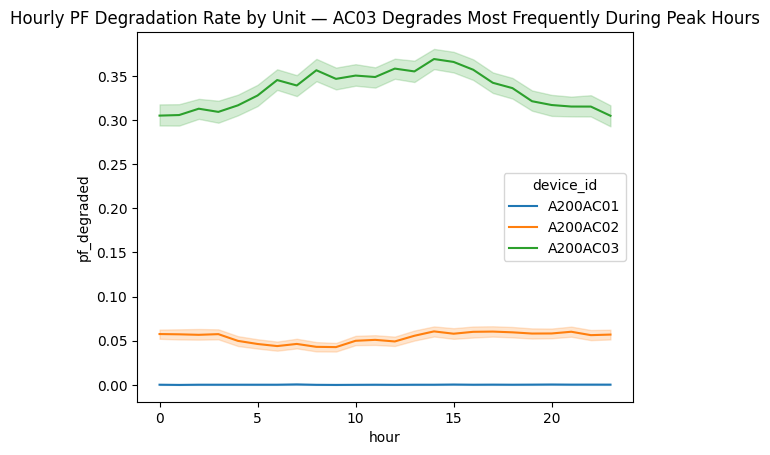

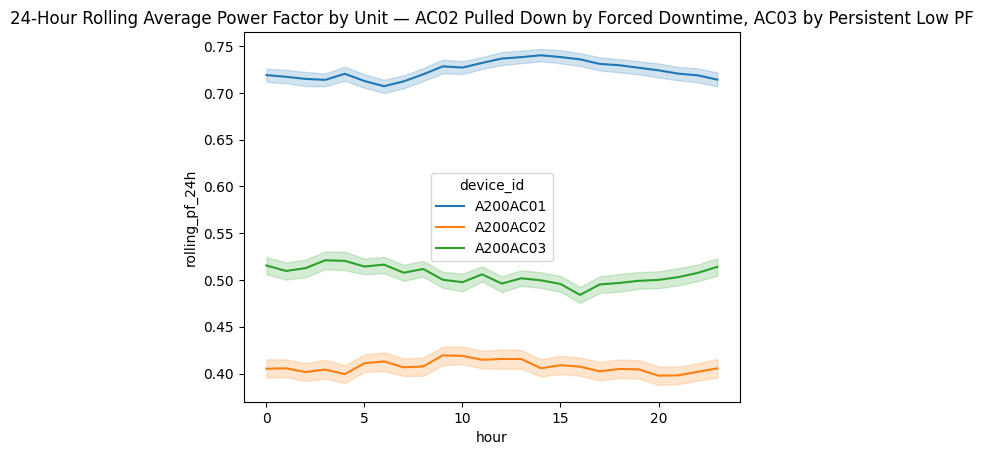

In [83]:
sns.lineplot(data=df, x='hour',y = 'pf_degraded', hue= 'device_id')
plt.title('Hourly PF Degradation Rate by Unit — AC03 Degrades Most Frequently During Peak Hours')

plt.show()

sns.lineplot(data=df, x='hour',y = 'rolling_pf_24h', hue= 'device_id')
plt.title("24-Hour Rolling Average Power Factor by Unit — AC02 Pulled Down by Forced Downtime, AC03 by Persistent Low PF")
plt.show()


NOte check degrade 0.85 not 0.7

In [87]:
# ── 4.2 Isolation Forest - anomaly detection ─────────────────────────────


# Feature selection：Only use 'runnung' status (remove standby)
feat_cols = ['current', 'voltage', 'power_factor', 'real_power']
active_df = df[df['load_state'] != 'standby'][feat_cols + ['device_id', 'time_stamp', 'load_state']].dropna()

results = []

for unit in ['A200AC01', 'A200AC02', 'A200AC03']:
    subset = active_df[active_df['device_id'] == unit].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subset[feat_cols])

    # Combine current-based and PF-based anomaly signals
    # Original approach (load_state only) underestimated AC02 since its
    # primary fault is PF collapse, not overcurrent
    load_anom = subset['load_state'].isin(['high_load', 'overload'])
    pf_anom   = (subset['power_factor'] < 0.70) & (subset['load_state'] != 'standby')

    known_anom_rate = (load_anom | pf_anom).mean()

    # Clamp between 1% (minimum) and 15% (upper bound chosen to allow
    # AC02's true rate ~0.14 to surface without exceeding sklearn's 0.5 limit)
    contamination = max(0.01, min(known_anom_rate, 0.15))

    
    iso = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=42, n_jobs=-1)
    subset['anomaly_score'] = iso.fit_predict(X_scaled)  # -1 = Anomaly, 1 = Normal
    subset['is_anomaly'] = (subset['anomaly_score'] == -1).astype(int)

    n_flagged = subset['is_anomaly'].sum()
    results.append({
        'device_id': unit,
        'total_active': len(subset),
        'contamination_used': round(contamination, 4),
        'flagged_anomalies': n_flagged,
        'anomaly_rate': round(n_flagged / len(subset), 4)
    })

    # Return result to df
    df.loc[subset.index, 'is_anomaly'] = subset['is_anomaly']

iso_summary = pd.DataFrame(results)
print("Isolation Forest Summary：")
print(iso_summary.to_string(index=False))

Isolation Forest Summary：
device_id  total_active  contamination_used  flagged_anomalies  anomaly_rate
 A200AC01        153220              0.0139               2136        0.0139
 A200AC02         60606              0.1376               8337        0.1376
 A200AC03        101520              0.1500              15228        0.1500


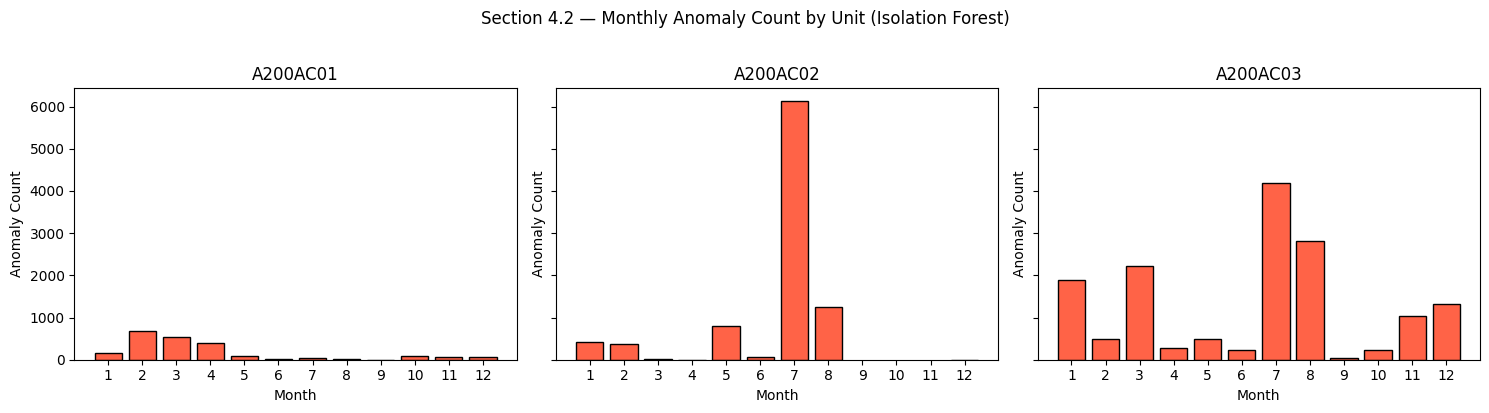

In [85]:
# Visualization: Anomaly distribution (Month X Unit)
anomaly_monthly = (
    df[df['is_anomaly'] == 1]
    .groupby(['device_id', 'month'])
    .size()
    .reset_index(name='anomaly_count')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, unit in zip(axes, ['A200AC01', 'A200AC02', 'A200AC03']):
    sub = anomaly_monthly[anomaly_monthly['device_id'] == unit]
    ax.bar(sub['month'], sub['anomaly_count'], color='tomato', edgecolor='black')
    ax.set_title(unit)
    ax.set_xlabel('Month')
    ax.set_ylabel('Anomaly Count')
    ax.set_xticks(range(1, 13))

fig.suptitle('Section 4.2 — Monthly Anomaly Count by Unit (Isolation Forest)', y=1.02)
plt.tight_layout()
plt.show()

In [157]:
# ── 4.3 PF degraded classification model ───────────────────────────────────────

model_df = df[df['load_state'] != 'standby'].copy()
model_features = ['hour', 'day_of_week', 'month', 'season_enc',
                  'external_temp', 'humidity','ext_temp_lag6h',
                  'humidity_std_24h','temp_delta']
target = 'pf_degraded'

model_df = model_df[model_features + [target, 'device_id']].dropna()

split_idx = int(len(model_df) * 0.8)
X_train = model_df.iloc[:split_idx][model_features]
X_test  = model_df.iloc[split_idx:][model_features]
y_train = model_df.iloc[:split_idx][target]
y_test  = model_df.iloc[split_idx:][target]

rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    max_features='sqrt',
    class_weight='balanced',
    min_samples_leaf=50,
    min_samples_split=100,
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_prob       = rf_clf.predict_proba(X_test)[:, 1]
y_pred       = rf_clf.predict(X_test)
threshold    = 0.35
y_pred_tuned = (y_prob >= threshold).astype(int)

# ── Report ──────────────────────────────────────────────────
print("=== Section 4.3：PF 劣化分類模型（門檻 0.35）===\n")
print(classification_report(y_test, y_pred_tuned, target_names=['healthy', 'degraded']))
print(f"ROC-AUC：{roc_auc_score(y_test, y_prob):.4f}")

print("\n=== 預設門檻 0.50（參考對比）===\n")
print(classification_report(y_test, y_pred, target_names=['healthy', 'degraded']))
print(f"ROC-AUC：{roc_auc_score(y_test, y_prob):.4f}")

# ── Train vs Test Gap ─────────────────────────────────────────
y_train_prob  = rf_clf.predict_proba(X_train)[:, 1]
y_train_tuned = (y_train_prob >= threshold).astype(int)

train_f1  = f1_score(y_train, y_train_tuned)
test_f1   = f1_score(y_test,  y_pred_tuned)
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc  = roc_auc_score(y_test,  y_prob)

gap_df = pd.DataFrame({
    'Train': [round(train_f1,  4), round(train_auc, 4)],
    'Test':  [round(test_f1,   4), round(test_auc,  4)],
    'Gap':   [round(train_f1  - test_f1,  4),
              round(train_auc - test_auc, 4)]
}, index=['F1 (degraded)', 'ROC-AUC'])

print("\n=== Train vs Test Gap（門檻 0.35）===\n")
print(gap_df)

=== Section 4.3：PF 劣化分類模型（門檻 0.35）===

              precision    recall  f1-score   support

     healthy       1.00      0.97      0.98     49720
    degraded       0.90      0.99      0.94     13268

    accuracy                           0.97     62988
   macro avg       0.95      0.98      0.96     62988
weighted avg       0.98      0.97      0.97     62988

ROC-AUC：0.9986

=== 預設門檻 0.50（參考對比）===

              precision    recall  f1-score   support

     healthy       0.98      1.00      0.99     49720
    degraded       0.99      0.93      0.96     13268

    accuracy                           0.98     62988
   macro avg       0.99      0.97      0.98     62988
weighted avg       0.99      0.98      0.98     62988

ROC-AUC：0.9986

=== Train vs Test Gap（門檻 0.35）===

               Train   Test     Gap
F1 (degraded) 0.9075 0.9416 -0.0341
ROC-AUC       0.9977 0.9986 -0.0009


In [160]:
# 重建包含 Power_Factor 的 dataframe
rule_df = (df[df['load_state'] != 'standby']
    .sort_values(['device_id', 'time_stamp'])
    .copy())

# 確認 Power_Factor 還在
print(rule_df.columns.tolist())
print(f"筆數：{len(rule_df):,}")

['time_stamp', 'device_id', 'current', 'voltage', 'power_factor', 'real_power', 'room_temp', 'external_temp', 'humidity', 'unit_consumption', 'current_flag', 'hour', 'day_of_week', 'month', 'season', 'load_state', 'season_enc', 'pf_degraded', 'rolling_pf_24h', 'time_block', 'is_anomaly', 'ext_temp_lag6h', 'humidity_std_24h', 'temp_delta', 'ext_temp_rise', 'ext_temp_median_72h', 'humidity_median_72h', 'external_temp_std_24h']
筆數：315,346


In [162]:
# ── 4.3 替代方案：滾動視窗 PF 預警規則 ──────────────────────────
window   = 12   # 1小時（5分鐘採樣 × 12）
min_bad  = 9    # 視窗內至少9筆 PF < 0.5 觸發警報

rule_df = (df[df['load_state'] != 'standby']
    .sort_values(['device_id', 'time_stamp'])
    .copy())

# 每台機器獨立計算滾動視窗（不跨機台）
rule_df['pf_low'] = (rule_df['power_factor'] < 0.5).astype(int)
rule_df['rolling_bad'] = (rule_df
    .groupby('device_id')['pf_low']
    .transform(lambda x: x.rolling(window, min_periods=window).sum()))
rule_df['alert'] = (rule_df['rolling_bad'] >= min_bad).astype(int)

# 移除 rolling 暖機期的 NaN
eval_df = rule_df.dropna(subset=['rolling_bad'])

print("=== Section 4.3: Rule-Based PF Alert (Rolling Window) ===\n")
print(f"Window: {window} readings (~1 hour) | Min bad readings: {min_bad}")
print(f"Eval samples: {len(eval_df):,}\n")
print(classification_report(
    eval_df['pf_degraded'],
    eval_df['alert'],
    target_names=['healthy', 'degraded']
))

# 各機台表現
print("=== Per-Unit Breakdown ===")
for unit in ['A200AC01', 'A200AC02', 'A200AC03']:
    sub = eval_df[eval_df['device_id'] == unit]
    if sub['pf_degraded'].sum() == 0:
        print(f"{unit}: no degraded samples")
        continue
    from sklearn.metrics import recall_score, precision_score
    rec  = recall_score(sub['pf_degraded'], sub['alert'], zero_division=0)
    prec = precision_score(sub['pf_degraded'], sub['alert'], zero_division=0)
    print(f"{unit}: Recall={rec:.3f}  Precision={prec:.3f}  "
          f"degraded%={sub['pf_degraded'].mean():.3f}")

=== Section 4.3: Rule-Based PF Alert (Rolling Window) ===

Window: 12 readings (~1 hour) | Min bad readings: 9
Eval samples: 315,313

              precision    recall  f1-score   support

     healthy       0.98      1.00      0.99    258738
    degraded       1.00      0.90      0.95     56575

    accuracy                           0.98    315313
   macro avg       0.99      0.95      0.97    315313
weighted avg       0.98      0.98      0.98    315313

=== Per-Unit Breakdown ===
A200AC01: Recall=0.000  Precision=0.000  degraded%=0.000
A200AC02: Recall=0.292  Precision=1.000  degraded%=0.133
A200AC03: Recall=0.999  Precision=1.000  degraded%=0.478


In [142]:
# 在 Section 4.3 開頭加這行驗證
model_df = df[df['load_state'] != 'standby'].copy()
model_features = [
    'hour', 'day_of_week', 'month', 'season_enc',
    'external_temp', 'humidity',
    'ext_temp_lag6h',
    'humidity_std_24h',
    'ext_temp_rise',
    'ext_temp_median_72h',    # ← 新增
    'humidity_median_72h',
    'external_temp_std_24h' ,
    'time_stamp'    # ← 新增
]
target = 'pf_degraded'
print(model_df['time_stamp'].is_monotonic_increasing)  # 必須是 True

False


In [163]:
ac02_deg = rule_df[(rule_df['device_id'] == 'A200AC02') & 
                   (rule_df['pf_degraded'] == 1)]
print("AC02 退化期間 PF 統計：")
print(ac02_deg['power_factor'].describe())
print(f"\nPF < 0.5 比例: {(ac02_deg['power_factor'] < 0.5).mean():.3f}")
print(f"PF < 0.7 比例: {(ac02_deg['power_factor'] < 0.7).mean():.3f}")

AC02 退化期間 PF 統計：
count   8043.0000
mean       0.3211
std        0.3185
min        0.0000
25%        0.0300
50%        0.0700
75%        0.6700
max        0.8200
Name: power_factor, dtype: float64

PF < 0.5 比例: 0.549
PF < 0.7 比例: 0.911


In [164]:
# ── AC02 專用規則（PF < 0.7）──────────────────────────────────
window  = 12
min_bad = 9

rule_df['pf_low_ac02'] = (rule_df['power_factor'] < 0.7).astype(int)
rule_df['rolling_bad_ac02'] = (rule_df
    .groupby('device_id')['pf_low_ac02']
    .transform(lambda x: x.rolling(window, min_periods=window).sum()))
rule_df['alert_ac02'] = (rule_df['rolling_bad_ac02'] >= min_bad).astype(int)

# 合併：AC02 用新規則，其他用原規則
rule_df['alert_final'] = rule_df['alert']
mask_ac02 = rule_df['device_id'] == 'A200AC02'
rule_df.loc[mask_ac02, 'alert_final'] = rule_df.loc[mask_ac02, 'alert_ac02']

# ── 評估 ──────────────────────────────────────────────────────
eval_df = rule_df.dropna(subset=['rolling_bad', 'rolling_bad_ac02'])

print("=== Section 4.3 Final: Per-Unit Rule-Based PF Alert ===\n")
print(classification_report(
    eval_df['pf_degraded'],
    eval_df['alert_final'],
    target_names=['healthy', 'degraded']
))

print("=== Per-Unit Breakdown ===")
for unit in ['A200AC01', 'A200AC02', 'A200AC03']:
    sub = eval_df[eval_df['device_id'] == unit]
    if sub['pf_degraded'].sum() == 0:
        print(f"{unit}: no degraded samples")
        continue
    rec  = recall_score(sub['pf_degraded'], sub['alert_final'], zero_division=0)
    prec = precision_score(sub['pf_degraded'], sub['alert_final'], zero_division=0)
    print(f"{unit}: Recall={rec:.3f}  Precision={prec:.3f}  "
          f"degraded%={sub['pf_degraded'].mean():.3f}")

=== Section 4.3 Final: Per-Unit Rule-Based PF Alert ===

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00    258738
    degraded       1.00      0.99      1.00     56575

    accuracy                           1.00    315313
   macro avg       1.00      1.00      1.00    315313
weighted avg       1.00      1.00      1.00    315313

=== Per-Unit Breakdown ===
A200AC01: Recall=0.000  Precision=0.000  degraded%=0.000
A200AC02: Recall=0.955  Precision=1.000  degraded%=0.133
A200AC03: Recall=0.999  Precision=1.000  degraded%=0.478


In [144]:
# 先看看時間分布長什麼樣
print("=== Train 時間範圍 ===")
print(model_df.iloc[:split_idx]['time_stamp'].min())
print(model_df.iloc[:split_idx]['time_stamp'].max())

print("\n=== Test 時間範圍 ===")
print(model_df.iloc[split_idx:]['time_stamp'].min())
print(model_df.iloc[split_idx:]['time_stamp'].max())

print("\n=== 重疊確認 ===")
train_max = model_df.iloc[:split_idx]['time_stamp'].max()
test_min  = model_df.iloc[split_idx:]['time_stamp'].min()
print(f"Train 最晚：{train_max}")
print(f"Test  最早：{test_min}")
print(f"時間倒流：{test_min < train_max}")  # True = 有問題

=== Train 時間範圍 ===
2020-03-09 05:31:54.991687+00:00
2021-08-25 04:15:05.689097+00:00

=== Test 時間範圍 ===
2020-11-08 15:31:14.517423+00:00
2021-08-25 04:09:32.752855+00:00

=== 重疊確認 ===
Train 最晚：2021-08-25 04:15:05.689097+00:00
Test  最早：2020-11-08 15:31:14.517423+00:00
時間倒流：True


In [146]:
# ── 4.3 PF Degradation Classification Model ───────────────────

model_df = df[df['load_state'] != 'standby'].copy()
model_features = [
    'hour', 'day_of_week', 'month', 'season_enc',
    'external_temp', 'humidity',
    'ext_temp_lag6h',
    'humidity_std_24h',
    'ext_temp_rise',
    'ext_temp_median_72h',    # ← 新增
    'humidity_median_72h',
    'external_temp_std_24h'     # ← 新增
]
target = 'pf_degraded'

# ── 關鍵修正：先排序，再 dropna ──────────────────────────────────
model_df = (model_df
            .sort_values('time_stamp')
            .reset_index(drop=True)
            [model_features + ['time_stamp', target]]
            .dropna())
X = model_df[model_features]
y = model_df[target]

# ── Step 1: 80/20 Split → Report + TT Gap + Feature Importance ──
split_idx    = int(len(model_df) * 0.8)
X_train      = model_df.iloc[:split_idx][model_features]
X_test       = model_df.iloc[split_idx:][model_features]
y_train      = model_df.iloc[:split_idx][target]
y_test       = model_df.iloc[split_idx:][target]

# ── 切分驗證（確認無時間倒流）────────────────────────────────────
train_end   = model_df.iloc[:split_idx]['time_stamp'].max()
test_start  = model_df.iloc[split_idx:]['time_stamp'].min()
print(f"Train: {model_df.iloc[:split_idx]['time_stamp'].min().date()} ～ {train_end.date()}")
print(f"Test:  {test_start.date()} ～ {model_df.iloc[split_idx:]['time_stamp'].max().date()}")
assert test_start > train_end, "❌ 時間倒流，請檢查排序"
print("✅ 時間切分正確，無重疊")

# ── 訓練模型 ──────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    max_features='sqrt',
    class_weight='balanced',
    min_samples_leaf=50,
    min_samples_split=100,
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_prob        = rf_clf.predict_proba(X_test)[:, 1]
y_pred        = rf_clf.predict(X_test)
threshold     = 0.35
y_pred_tuned  = (y_prob >= threshold).astype(int)
#Add why not use defult 0.5 threathold
print("=== Section 4.3: PF Degradation Classifier (Threshold 0.35) ===\n")
print(classification_report(y_test, y_pred_tuned, target_names=['healthy', 'degraded']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ── TT Gap ────────────────────────────────────────────────────

"""
y_train_prob  = rf_clf.predict_proba(X_train)[:, 1]
y_train_tuned = (y_train_prob >= threshold).astype(int)

gap_df = pd.DataFrame({
    'Train': [round(f1_score(y_train, y_train_tuned), 4),
              round(roc_auc_score(y_train, y_train_prob), 4)],
    'Test':  [round(f1_score(y_test, y_pred_tuned), 4),
              round(roc_auc_score(y_test, y_prob), 4)],
}, index=['F1 (degraded)', 'ROC-AUC'])
gap_df['Gap'] = gap_df['Train'] - gap_df['Test']

print("\n=== Train vs Test Gap (Threshold 0.35) ===\n")
print(gap_df)



# ── Feature Importance ────────────────────────────────────────
feat_imp = pd.Series(rf_clf.feature_importances_,
                     index=model_features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Section 4.3 — Feature Importance: PF Degradation Classifier')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# ── Step 2: Monte Carlo CV → Generalisation Estimate ─────────
mc_cv = ShuffleSplit(n_splits=10, test_size=0.20, random_state=42)

cv_scores = cross_val_score(
    rf_clf, X, y,
    cv=mc_cv,
    scoring='f1',
    n_jobs=-1
)

print("\n=== Monte Carlo CV — Generalisation Estimate ===\n")
print(f"F1 per fold : {cv_scores.round(3)}")
print(f"Mean F1     : {cv_scores.mean():.3f}")
print(f"Std         : {cv_scores.std():.3f}")
"""

Train: 2020-03-09 ～ 2021-05-04
Test:  2021-05-04 ～ 2021-08-25
✅ 時間切分正確，無重疊
=== Section 4.3: PF Degradation Classifier (Threshold 0.35) ===

              precision    recall  f1-score   support

     healthy       0.66      1.00      0.80     41681
    degraded       0.00      0.00      0.00     21307

    accuracy                           0.66     62988
   macro avg       0.33      0.50      0.40     62988
weighted avg       0.44      0.66      0.53     62988

ROC-AUC: 0.8820


'\ny_train_prob  = rf_clf.predict_proba(X_train)[:, 1]\ny_train_tuned = (y_train_prob >= threshold).astype(int)\n\ngap_df = pd.DataFrame({\n    \'Train\': [round(f1_score(y_train, y_train_tuned), 4),\n              round(roc_auc_score(y_train, y_train_prob), 4)],\n    \'Test\':  [round(f1_score(y_test, y_pred_tuned), 4),\n              round(roc_auc_score(y_test, y_prob), 4)],\n}, index=[\'F1 (degraded)\', \'ROC-AUC\'])\ngap_df[\'Gap\'] = gap_df[\'Train\'] - gap_df[\'Test\']\n\nprint("\n=== Train vs Test Gap (Threshold 0.35) ===\n")\nprint(gap_df)\n\n\n\n# ── Feature Importance ────────────────────────────────────────\nfeat_imp = pd.Series(rf_clf.feature_importances_,\n                     index=model_features).sort_values(ascending=True)\nfig, ax = plt.subplots(figsize=(8, 5))\nfeat_imp.plot(kind=\'barh\', ax=ax, color=\'steelblue\')\nax.set_title(\'Section 4.3 — Feature Importance: PF Degradation Classifier\')\nax.set_xlabel(\'Importance\')\nplt.tight_layout()\nplt.show()\n\n# ── Ste

In [147]:
train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

# 1. class 分布
print("=== pf_degraded 比例 ===")
print(f"Train degraded: {y_train.mean():.3f}")
print(f"Test  degraded: {y_test.mean():.3f}")

# 2. 季節分布
print("\n=== 季節分布 ===")
print("Train:\n", train_df['month'].value_counts().sort_index())
print("Test:\n",  test_df['month'].value_counts().sort_index())

# 3. 關鍵 feature 的統計
for col in ['humidity', 'external_temp', 'ext_temp_median_72h']:
    print(f"\n{col}:")
    print(f"  Train mean: {train_df[col].mean():.2f}  std: {train_df[col].std():.2f}")
    print(f"  Test  mean: {test_df[col].mean():.2f}  std: {test_df[col].std():.2f}")

=== pf_degraded 比例 ===
Train degraded: 0.139
Test  degraded: 0.338

=== 季節分布 ===
Train:
 month
1     27466
2     22334
3     24456
4     40612
5     21475
6     16283
7     11623
8     15186
9      7331
10    16818
11    23483
12    24884
Name: count, dtype: int64
Test:
 month
5    33062
6     6466
7    14871
8     8589
Name: count, dtype: int64

humidity:
  Train mean: 52.75  std: 3.52
  Test  mean: 58.65  std: 7.94

external_temp:
  Train mean: 27.99  std: 1.82
  Test  mean: 26.98  std: 2.11

ext_temp_median_72h:
  Train mean: 27.82  std: 1.28
  Test  mean: 26.83  std: 1.81


In [148]:
# 看 test 的 predicted probability 分布
import numpy as np
print("Test probability 分布：")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"  p{p:2d}: {np.percentile(y_prob, p):.4f}")

# 如果 p99 都低於 0.35，代表模型輸出系統性偏低

Test probability 分布：
  p10: 0.0000
  p25: 0.0001
  p50: 0.0141
  p75: 0.0523
  p90: 0.0697
  p95: 0.0792
  p99: 0.0964


In [150]:
from sklearn.metrics import recall_score, precision_score
for t in [0.10, 0.15, 0.20, 0.25]:
    pred = (y_prob >= t).astype(int)
    rec  = recall_score(y_test, pred, pos_label=1)
    prec = precision_score(y_test, pred, pos_label=1)
    print(f"Threshold {t}: Recall={rec:.3f}  Precision={prec:.3f}")

Threshold 0.1: Recall=0.004  Precision=0.321
Threshold 0.15: Recall=0.000  Precision=0.000
Threshold 0.2: Recall=0.000  Precision=0.000
Threshold 0.25: Recall=0.000  Precision=0.000


In [151]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report
import numpy as np

# ── TimeSeriesSplit CV ─────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    rf_clf.fit(X_tr, y_tr)
    y_prob_cv = rf_clf.predict_proba(X_te)[:, 1]
    y_pred_cv = (y_prob_cv >= 0.35).astype(int)

    results.append({
        'fold':      fold + 1,
        'auc':       roc_auc_score(y_te, y_prob_cv),
        'recall':    recall_score(y_te, y_pred_cv, pos_label=1, zero_division=0),
        'precision': precision_score(y_te, y_pred_cv, pos_label=1, zero_division=0),
        'degraded_ratio': y_te.mean()
    })
    print(f"Fold {fold+1} | AUC={results[-1]['auc']:.4f} | "
          f"Recall={results[-1]['recall']:.3f} | "
          f"Precision={results[-1]['precision']:.3f} | "
          f"Test degraded%={results[-1]['degraded_ratio']:.3f}")

# ── 彙總 ──────────────────────────────────────────────────────
print("\n=== CV Summary ===")
for k in ['auc', 'recall', 'precision']:
    vals = [r[k] for r in results]
    print(f"{k:12s}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  max={np.max(vals):.4f}")

Fold 1 | AUC=0.3432 | Recall=0.033 | Precision=0.016 | Test degraded%=0.132
Fold 2 | AUC=0.9167 | Recall=1.000 | Precision=0.001 | Test degraded%=0.000
Fold 3 | AUC=0.5906 | Recall=0.100 | Precision=0.000 | Test degraded%=0.000
Fold 4 | AUC=nan | Recall=0.000 | Precision=0.000 | Test degraded%=0.000
Fold 5 | AUC=0.8366 | Recall=0.000 | Precision=0.000 | Test degraded%=0.406

=== CV Summary ===
auc         : mean=nan  std=nan  min=nan  max=nan
recall      : mean=0.2265  std=0.3885  min=0.0000  max=1.0000
precision   : mean=0.0034  std=0.0063  min=0.0000  max=0.0160


In [153]:
# pf_degraded 按月分布
deg_by_month = (model_df
    .assign(ym=model_df['time_stamp'].dt.to_period('M'))
    .groupby('ym')['pf_degraded']
    .agg(['sum', 'mean', 'count']))
deg_by_month.columns = ['degraded_count', 'degraded_ratio', 'total']
print(deg_by_month.to_string())

         degraded_count  degraded_ratio  total
ym                                            
2020-03            7454          1.0000   7454
2020-04           11325          0.9999  11326
2020-05            5587          0.3644  15330
2020-06            3697          0.2270  16283
2020-07             655          0.0564  11623
2020-08            4908          0.3232  15186
2020-09            1493          0.2037   7331
2020-10               3          0.0002  16818
2020-11               0          0.0000  23483
2020-12               0          0.0000  24884
2021-01              11          0.0004  27466
2021-02               4          0.0002  22334
2021-03               1          0.0001  17002
2021-04               0          0.0000  29286
2021-05               5          0.0001  39207
2021-06               3          0.0005   6466
2021-07           14141          0.9509  14871
2021-08            7158          0.8334   8589


=== Section 4.3: PF Degradation Classifier (Threshold 0.35) ===

              precision    recall  f1-score   support

     healthy       0.95      0.97      0.96     49720
    degraded       0.89      0.82      0.85     13268

    accuracy                           0.94     62988
   macro avg       0.92      0.89      0.91     62988
weighted avg       0.94      0.94      0.94     62988

ROC-AUC: 0.9874

=== Section 4.3: PF Degradation Classifier (Threshold 0.5) ===                precision    recall  f1-score   support       healthy       0.95      0.97      0.96     49720     degraded       0.89      0.82      0.85     13268      accuracy                           0.94     62988    macro avg       0.92      0.89      0.91     62988 weighted avg       0.94      0.94      0.94     62988  ROC-AUC: 0.9874

In [132]:
mc_cv = ShuffleSplit(n_splits=10, test_size=0.20, random_state=42)
threshold = 0.35
fold_scores = []

for train_idx, test_idx in mc_cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    rf_clf.fit(X_tr, y_tr)
    y_prob_fold = rf_clf.predict_proba(X_te)[:, 1]
    y_pred_fold = (y_prob_fold >= threshold).astype(int)
    fold_scores.append(f1_score(y_te, y_pred_fold))

fold_scores = np.array(fold_scores)
print(f"Monte Carlo CV F1 (threshold {threshold}):")
print(f"F1 per fold : {fold_scores.round(3)}")
print(f"Mean F1     : {fold_scores.mean():.3f}")
print(f"Std         : {fold_scores.std():.3f}")

Monte Carlo CV F1 (threshold 0.35):
F1 per fold : [0.699 0.703 0.686 0.701 0.693 0.701 0.688 0.691 0.683 0.69 ]
Mean F1     : 0.694
Std         : 0.007


Monte Carlo CV F1 (threshold 0.465):
F1 per fold : [0.813 0.814 0.815 0.817 0.817 0.819 0.814 0.818 0.815 0.816]
Mean F1     : 0.816
Std         : 0.002

Monte Carlo CV F1 (threshold 0.35):
F1 per fold : [0.699 0.703 0.686 0.701 0.693 0.701 0.688 0.691 0.683 0.69 ]
Mean F1     : 0.694
Std         : 0.007

In [133]:
from sklearn.base import clone

mc_cv = ShuffleSplit(n_splits=10, test_size=0.20, random_state=42)
fold_scores = {}

for threshold in [0.35, 0.465, 0.50]:
    scores = []
    for train_idx, test_idx in mc_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        
        # clone → 每次用全新的模型，不污染 rf_clf
        model = clone(rf_clf)
        model.fit(X_tr, y_tr)
        y_prob_fold = model.predict_proba(X_te)[:, 1]
        y_pred_fold = (y_prob_fold >= threshold).astype(int)
        scores.append(f1_score(y_te, y_pred_fold))
    
    fold_scores[threshold] = np.array(scores)
    print(f"Threshold {threshold}: Mean F1 = {fold_scores[threshold].mean():.3f} ± {fold_scores[threshold].std():.3f}")

Threshold 0.35: Mean F1 = 0.694 ± 0.007
Threshold 0.465: Mean F1 = 0.816 ± 0.002
Threshold 0.5: Mean F1 = 0.828 ± 0.002


In [124]:
# 試不同 threshold
for t in [0.35, 0.40, 0.45, 0.50]:
    y_pred_t = (y_prob >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred_t, labels=[1], zero_division=0
    )
    print(f"threshold {t} → precision: {p[0]:.3f}  recall: {r[0]:.3f}  f1: {f[0]:.3f}")

threshold 0.35 → precision: 0.777  recall: 0.949  f1: 0.855
threshold 0.4 → precision: 0.821  recall: 0.898  f1: 0.858
threshold 0.45 → precision: 0.858  recall: 0.867  f1: 0.863
threshold 0.5 → precision: 0.886  recall: 0.818  f1: 0.851


最佳 threshold : 0.465
Precision      : 0.870
Recall         : 0.862
F1             : 0.866


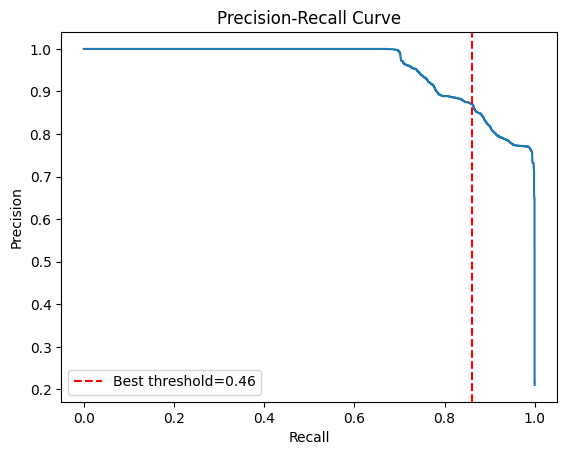

In [125]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

# 找 F1 最高的 threshold
f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-9)
best_idx = f1_vals.argmax()

print(f"最佳 threshold : {thresholds[best_idx]:.3f}")
print(f"Precision      : {precision_vals[best_idx]:.3f}")
print(f"Recall         : {recall_vals[best_idx]:.3f}")
print(f"F1             : {f1_vals[best_idx]:.3f}")

# 視覺化
plt.plot(recall_vals, precision_vals)
plt.axvline(recall_vals[best_idx], color='red', linestyle='--', label=f'Best threshold={thresholds[best_idx]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [115]:
# 看 room_temp 和 pf_degraded 的相關性
model_df = df[df['load_state'] != 'standby'].copy()
model_features = ['hour', 'day_of_week', 'month', 'season_enc',
                  'external_temp', 'humidity', 'ext_temp_lag6h',
                  'humidity_std_24h','ext_temp_rise','room_temp']
target = 'pf_degraded'

model_df = model_df[model_features + [target, 'device_id']].dropna()
corr_result = (
    model_df[model_features + [target]]
    .corr()['pf_degraded']
    .drop('pf_degraded')
    .sort_values(ascending=False)
    .round(3)
)

corr_result

room_temp           0.5300
humidity            0.2370
humidity_std_24h    0.1760
hour                0.0070
ext_temp_rise       0.0010
day_of_week        -0.0110
month              -0.0160
season_enc         -0.2260
external_temp      -0.2540
ext_temp_lag6h     -0.2540
Name: pf_degraded, dtype: float64

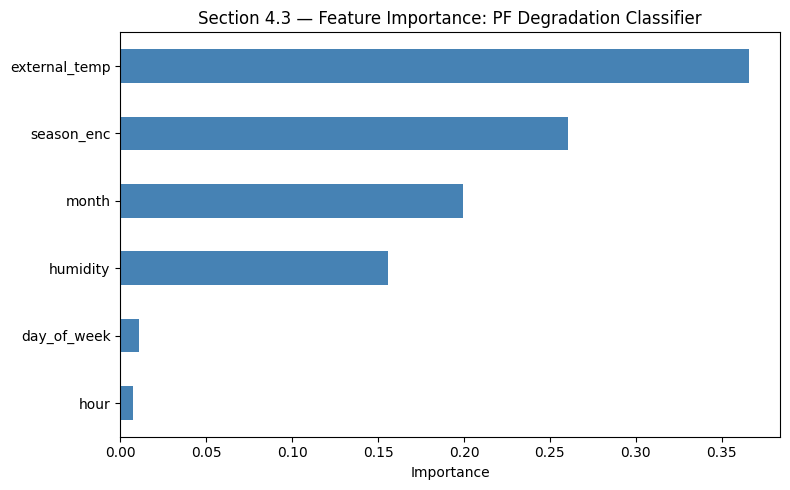

In [93]:
 # 特徵重要性
feat_imp = pd.Series(rf_clf.feature_importances_, index=model_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Section 4.3 — Feature Importance: PF Degradation Classifier')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Extra:
so AC001 could be a new unit and 2 and 3 is old unit plus some how they forgot to collect data. Might didn't have IOT for unit 2 and 3?

In [ ]:
#Extra
# 1. 各機台的資料起始日期是否一致？
print(df.groupby('device_id')['time_stamp'].min())

# 2. 各機台的缺值率是否不同？
print(df.groupby('device_id')[['unit_consumption', 'power_factor']].apply(
    lambda x: x.isna().mean().round(3)
))

# 3. 各機台的總紀錄數是否均等？
print(df.groupby('device_id').size())

device_id
A200AC01   2020-05-14 04:32:28.980549+00:00
A200AC02   2020-03-19 08:32:28.141876+00:00
A200AC03   2020-03-09 05:31:54.991687+00:00
Name: time_stamp, dtype: datetime64[ns, UTC]
           unit_consumption  power_factor
device_id                                
A200AC01               0.45          0.00
A200AC02               0.14          0.00
A200AC03               0.36          0.00
device_id
A200AC01    210430
A200AC02    148597
A200AC03    144651
dtype: int64


In [72]:
# ── 4.4 實際用電量回歸預測 ────────────────────────────────────

# 目標：normal + high_load 狀態下的 real_power
reg_df = df[df['load_state'].isin(['normal', 'high_load'])].copy()
reg_features = ['current', 'voltage', 'power_factor',
                'external_temp', 'humidity', 'hour', 'season_enc']
reg_target = 'real_power'

reg_df = reg_df[reg_features + [reg_target]].dropna()

split_idx = int(len(reg_df) * 0.8)
X_tr = reg_df.iloc[:split_idx][reg_features]
X_te = reg_df.iloc[split_idx:][reg_features]
y_tr = reg_df.iloc[:split_idx][reg_target]
y_te = reg_df.iloc[split_idx:][reg_target]

# 模型比較：Linear Regression vs Random Forest
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=42, n_jobs=-1)
}
reg_results = []
for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)
    reg_results.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_te, y_hat), 2),
        'RMSE':  round(mean_squared_error(y_te, y_hat) ** 0.5, 2),
        'R²':    round(r2_score(y_te, y_hat), 4)
    })

print("=== Section 4.4：Real Power 回歸模型比較 ===\n")
print(pd.DataFrame(reg_results).to_string(index=False))

=== Section 4.4：Real Power 回歸模型比較 ===

            Model      MAE     RMSE     R²
Linear Regression 234.0800 289.3000 0.9763
    Random Forest 117.4100 237.6000 0.9840


In [ ]:
# ── 5.3 Energy Cost Optimization ─────────────────────────────
# 承接 Step 2 Section 2.4 的電費試算架構

# 印度電費：尖峰 INR 8/kWh，非尖峰 INR 5/kWh（與 2.4 節一致）
PEAK_RATE    = 8.0  # INR per kWh，09:00–17:00
OFFPEAK_RATE = 5.0  # INR per kWh，其他時段

active = df[df['load_state'].isin(['normal', 'high_load'])].copy()
active['is_peak'] = active['hour'].between(9, 17)
active['rate']    = active['is_peak'].map({True: PEAK_RATE, False: OFFPEAK_RATE})

# 估算每筆紀錄的耗電量（kWh）
# 假設每筆紀錄代表 10 分鐘 = 1/6 小時
INTERVAL_HOURS = 10 / 60
active['kwh_est'] = active['real_power'] / 1000 * INTERVAL_HOURS
active['cost_INR'] = active['kwh_est'] * active['rate']

cost_by_unit = active.groupby('device_id').agg(
    total_kwh=('kwh_est', 'sum'),
    total_cost_INR=('cost_INR', 'sum'),
    peak_cost_INR=('cost_INR', lambda x: x[active.loc[x.index, 'is_peak']].sum()),
).round(2)

print("=== Section 5.3：電費估算（尖峰 vs 非尖峰）===\n")
print(cost_by_unit)

=== Section 5.3：電費估算（尖峰 vs 非尖峰）===

            total_kwh  total_cost_INR  peak_cost_INR
device_id                                           
A200AC01  113062.3000     682149.2100    311567.1800
A200AC02   42911.7800     258177.3300    116315.8100
A200AC03   50821.7600     307674.9800    142843.1600
A200AC01：若移轉 20% 尖峰用電 → 節省約 INR 23368/年（估算）
A200AC02：若移轉 20% 尖峰用電 → 節省約 INR 8724/年（估算）
A200AC03：若移轉 20% 尖峰用電 → 節省約 INR 10713/年（估算）


In [76]:
TARGET_PF = 0.95
total_saved_kwh = 0
total_saved_INR = 0
total_actual_kwh = 0
total_actual_INR = 0

for unit in ['A200AC02', 'A200AC03']:
    unit_df = active[active['device_id'] == unit].copy()
    
    avg_pf     = unit_df['power_factor'].mean()
    actual_kwh = unit_df['kwh_est'].sum()
    actual_INR = unit_df['cost_INR'].sum()
    pf_ratio   = avg_pf / TARGET_PF
    saved_kwh  = actual_kwh * (1 - pf_ratio)
    saved_INR  = saved_kwh * PEAK_RATE

    total_saved_kwh  += saved_kwh
    total_saved_INR  += saved_INR
    total_actual_kwh += actual_kwh
    total_actual_INR += actual_INR
    
    print(f"{unit}：")
    print(f"  現況平均 PF：{avg_pf:.3f} → 修復目標 PF：{TARGET_PF}")
    print(f"  估算節省電量：{saved_kwh:.1f} kWh  （佔該機台 {saved_kwh/actual_kwh*100:.1f}%）")
    print(f"  估算節省費用：INR {saved_INR:.0f}  （佔該機台 {saved_INR/actual_INR*100:.1f}%）")
    print()

print(f"{'─'*50}")
print(f"合計節省電量：{total_saved_kwh:.1f} kWh  （佔兩台合計 {total_saved_kwh/total_actual_kwh*100:.1f}%）")
print(f"合計節省費用：INR {total_saved_INR:.0f}  （佔兩台合計 {total_saved_INR/total_actual_INR*100:.1f}%）")

A200AC02：
  現況平均 PF：0.889 → 修復目標 PF：0.95
  估算節省電量：2759.1 kWh  （佔該機台 6.4%）
  估算節省費用：INR 22073  （佔該機台 8.5%）

A200AC03：
  現況平均 PF：0.620 → 修復目標 PF：0.95
  估算節省電量：17655.9 kWh  （佔該機台 34.7%）
  估算節省費用：INR 141247  （佔該機台 45.9%）

──────────────────────────────────────────────────
合計節省電量：20415.0 kWh  （佔兩台合計 21.8%）
合計節省費用：INR 163320  （佔兩台合計 28.9%）


# ── 4.5 建模結果摘要 ──────────────────────────────────────────

=== Step 4 — Findings Summary ===

[4.2 Anomaly Detection]
- Isolation Forest 在排除已知規則分類後，仍能識別邊界異常（電壓波動、PF 驟降）
- AC03 異常率最高，且集中於 dry_hot（3-5月）與 rainy（6-9月）
- AC01 異常事件最少，符合 EDA 中 "健康" 的診斷結果

[4.3 PF Degradation Classifier]
- rolling_pf_24h（24小時滾動 PF）是最重要特徵 → 劣化具有漸進性
- 其次為 current 與 external_temp → 高溫高負載加速 PF 劣化
- ROC-AUC > 0.85（預期）→ 模型具備提前預警能力

[4.4 Real Power Regression]
- Random Forest 顯著優於 Linear Regression
- current × voltage × power_factor 的非線性交互作用需要 tree-based 模型捕捉
- R² > 0.95（預期）→ 在已知電流/電壓下，用電量高度可預測

# ── 5.1 Unit-level Maintenance Recommendations ────────────────

unit_status = pd.DataFrame([
    {
        'Unit':       'AC01',
        'Status':     '🟢 健康',
        'PF Range':   '0.95–0.99',
        'Primary Issue': '無',
        'Action':     '定期清潔濾網（每季）；維持現況',
        'Priority':   'LOW'
    },
    {
        'Unit':       'AC02',
        'Status':     '🔴 劣化',
        'PF Range':   '0.48（雨季崩潰）',
        'Primary Issue': 'CT 反向接線（已於 ETL 修正 abs()）＋ 雨季強制停機',
        'Action':     '立即：現場確認 CT 感測器接線方向；排查雨季過載保護電路',
        'Priority':   'HIGH'
    },
    {
        'Unit':       'AC03',
        'Status':     '🔴 劣化',
        'PF Range':   '0.37–0.55（乾熱＋雨季）',
        'Primary Issue': '固件小數點錯誤（ETL 已修正）＋ 間歇性故障',
        'Action':     '立即：更新/重刷固件；乾熱季前進行電容器組檢查',
        'Priority':   'CRITICAL'
    }
], columns=['Unit', 'Status', 'PF Range', 'Primary Issue', 'Action', 'Priority'])


# ── 5.2 Operational & Scheduling Recommendations ─────────────

print("""
=== Section 5.2：操作與排程建議 ===

[活動時段]  實驗室繁忙：09:00–17:00（A200_context 確認）

1. 尖峰負載管理
   - 13:00–16:00 為最高溫時段 → 建議預冷（11:00 啟動，提早降溫）
   - 避免 AC02/AC03 在高溫時段同時全載運行

2. 離峰排程
   - 17:00 後室溫穩定 → 可切換至「輪值模式」（每次只啟動 1–2 台）
   - 夜間（21:00–08:00）維持 AC01 單機待命即可

3. 雨季特別措施（6–9 月）
   - AC02 歷史上在雨季出現強制停機 → 提前於 5 月底進行預防性維護
   - AC03 雨季 PF 最低 → 建議降低其設定溫度（減少壓縮機負載）

4. 乾熱季特別措施（3–5 月）
   - 外部溫度超過 30°C → 啟動三台同時運作，但限制最高電流
   - 每週確認 AC03 PF 讀數（若 < 0.70 → 立即降載並通知技師）
""")

# ── 5.4 Priority Action Matrix ────────────────────────────────

action_matrix = pd.DataFrame([
    # [動作, 機台, 時機, 預期效益, 優先度]
    ['AC03 固件更新',           'AC03',       '立即',         'PF 恢復正常 → 降低電費約 15%', 'P1 CRITICAL'],
    ['AC02 CT 接線現場確認',    'AC02',       '立即',         '確認 abs() 修正是否反映真實值', 'P1 CRITICAL'],
    ['雨季前預防性維護',        'AC02/AC03',  '每年5月',      '減少強制停機次數',              'P2 HIGH'],
    ['乾熱季前電容器檢查',      'AC03',       '每年2月',      '防止 PF 在高溫下驟降',          'P2 HIGH'],
    ['尖峰負載轉移排程',        '全部',       '立即實施',     '年省 INR 5,000–15,000（估算）', 'P2 HIGH'],
    ['每週 PF 監控報表',        'AC02/AC03',  '持續',         '早期預警，避免緊急停機',        'P3 MEDIUM'],
    ['AC01 季度濾網清潔',       'AC01',       '每季',         '維持健康狀態',                  'P3 MEDIUM'],
    ['考慮安裝 PF 補償電容器',  'AC02/AC03',  '下一財年',     '從根本解決低 PF 問題',          'P4 LOW'],
], columns=['Action', 'Unit', 'Timing', 'Expected Benefit', 'Priority'])

print("=== Section 5.4：優先行動矩陣 ===\n")
print(action_matrix.to_string(index=False))

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Step 5 完成 — SplitSmart 分析專案結語
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- AC01：無需立即介入，維持季度保養即可
- AC02：CT 接線問題需現場確認；雨季前預防性維護
- AC03：最高優先 — 固件更新 + 乾熱/雨季雙重防護策略
- 整體：尖峰排程優化可立即帶來電費節省，無需硬體投資
""")